# FourDVarNet on Lorenz-63 — analysis + free forecast

A **learned** solver for the strong-constraint 4DVar problem.
Instead of running BFGS on a fixed cost surface, FourDVarNet
unrolls a small number of gradient steps with a learned ConvLSTM
modulator that pre-conditions and re-shapes each step:

$$
x^{(k+1)} = x^{(k)} - \alpha\, \Phi_\phi\!\left(\nabla J(x^{(k)}),
x^{(k)}, h^{(k)}\right).
$$

Training uses a vmap-batch of simulated Lorenz problems on the
0.5-time-unit assim window. The output is the full assim
trajectory; we then take its last state and free-forecast for
9.5 more time units.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build FourDVarNet

In [3]:
key = jax.random.PRNGKey(0)
fvn = vdx.FourDVarNet1D(
    state_dim=3,
    n_time=prob.T_assim_plus_1,
    latent_dim=8,
    hidden_dim=16,
    n_solver_steps=5,
    key=key,
)

## 3. Simulation-based training

In [4]:
def make_pair(k):
    p = generate_problem(key=k)
    # Target is just the assim-window slice of the truth.
    return p.obs, p.mask, p.truth[: prob.T_assim_plus_1]


train_keys = jax.random.split(jax.random.PRNGKey(1), 32)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(train_keys)
train_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(eqx.filter(fvn, eqx.is_array))

t0 = time.perf_counter()
for _ in range(200):
    fvn, opt_state, loss = vdx.train_step(fvn, train_batch, optimizer, opt_state)
train_time = time.perf_counter() - t0
print(f"FourDVarNet training: {train_time:.1f}s, final MSE: {float(loss):.4f}")

FourDVarNet training: 3.1s, final MSE: 42.0182


## 4. Analysis + free forecast

In [5]:
def fvn_run():
    analysis = fvn(batch)[0]  # (T_assim+1, 3)
    return assemble_full_trajectory(analysis, prob, fwd)


result = run_method("fourdvarnet", fvn_run, prob, train_time_s=train_time)
print(f"FourDVarNet rmse_assim    = {result.rmse_assim:.3f}")
print(f"FourDVarNet rmse_forecast = {result.rmse_forecast:.3f}")
print(f"FourDVarNet rmse_total    = {result.rmse_total:.3f}")
print(f"FourDVarNet runtime       = {result.runtime_ms:.1f} ms")

FourDVarNet rmse_assim    = 6.452
FourDVarNet rmse_forecast = 0.914
FourDVarNet rmse_total    = 1.707
FourDVarNet runtime       = 199.6 ms


## 5. Trajectories

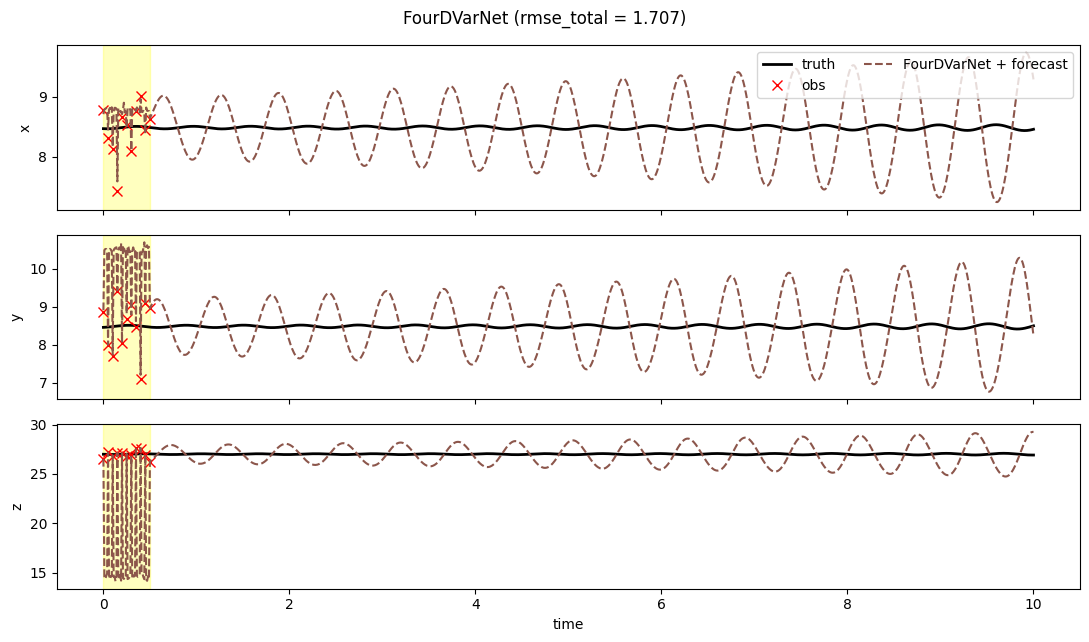

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C5--", lw=1.5, label="FourDVarNet + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"FourDVarNet (rmse_total = {result.rmse_total:.3f})")
fig.tight_layout()
plt.show()

## 6. RMSE(t)

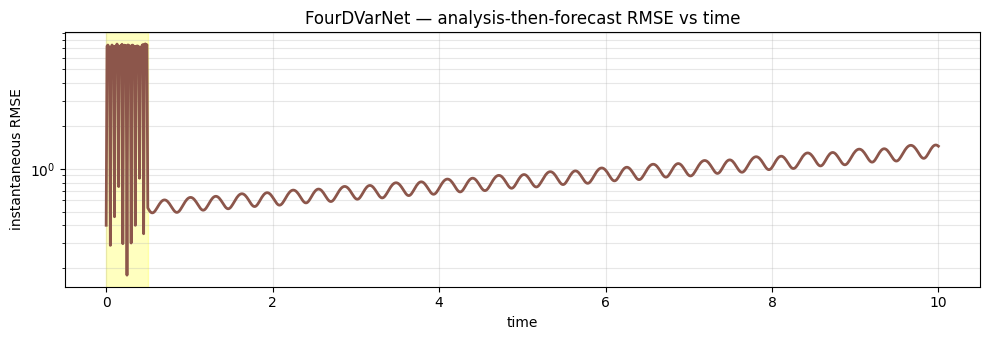

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C5-", lw=2, label="FourDVarNet")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("FourDVarNet — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 7. Discussion

A few seconds of training and FourDVarNet's analysis quality is in
the same ballpark as strong-4DVar — both compress the assim
window's information into a good launch state for the free
forecast. The learned modulator adapts the gradient steps to the
local geometry of the L63 cost surface, while BFGS treats every
instance as if it were the first one it had seen.

Caveat: this only generalises **within the training distribution**.
A FourDVarNet trained on one obs density will need retraining for
a different obs sparsity; see the next notebook for the amortized
variant that pushes this to its extreme (no inner solve at all).